In [ ]:
%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
import time
notebook_start = time.perf_counter()

import  os, json, pandas as pd, numpy as np, joblib, matplotlib.pyplot as plt, thermoift.PLOT_SETTINGS as ps
from    thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics
from    thermoift.rng_utils import get_rng
from    sklearn.model_selection import train_test_split, cross_validate
from    sklearn.inspection import permutation_importance
import  shap
from    tabpfn_extensions.interpretability.shap import get_shap_values

In [2]:
PLOT_FOLDER     = "TabPFN_OUTPUTS"
SLURM_RUN_FULL  = False
TEST_ROWS       = None
SEED            = 50015

In [ ]:
try:
    import tabpfn
    from tabpfn import TabPFNRegressor
    from tabpfn.constants import ModelVersion
    from tabpfn_extensions.hpo import TunedTabPFNRegressor

    if SLURM_RUN_FULL:
        os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"

    print(f"TabPFN version: {tabpfn.__version__}")
    print("Selected model version:", ModelVersion.V2)

except ImportError as exc:
    raise ImportError("tabpfn is not installed in this Python environment.") from exc

# Respect SLURM CPU allocation — prevents all 254 node CPUs being grabbed
n_cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", 4))
os.environ["OMP_NUM_THREADS"]      = str(n_cpus)
os.environ["MKL_NUM_THREADS"]      = str(n_cpus)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cpus)
os.environ["NUMEXPR_NUM_THREADS"]  = str(n_cpus)
try:
    import torch
    torch.set_num_threads(n_cpus)
except ImportError:
    pass
print(f"Thread limit set to {n_cpus} (SLURM_CPUS_PER_TASK)")

In [4]:
df = pd.read_csv("../interfacial_results_dataset_A4.csv")
print(f"Number of rows: {len(df)}")

if isinstance(TEST_ROWS, str) and TEST_ROWS.strip().lower() in ("", "none", "null"):
    TEST_ROWS = None
if TEST_ROWS is not None:
    TEST_ROWS = int(TEST_ROWS)
    df = df.iloc[:TEST_ROWS].copy()
    print(f"Test mode: using first {TEST_ROWS} rows only")
else:
    print("Full mode: using all rows")

print(f"Total samples: {len(df)}")
print(f"\nP_bubble statistics:")
print(df["P_bubble"].describe())

Number of rows: 19171
Test mode: using first 100 rows only
Total samples: 100

P_bubble statistics:
count    100.000000
mean      38.602617
std        2.619909
min       35.970519
25%       36.267849
50%       37.730702
75%       40.496295
max       43.861234
Name: P_bubble, dtype: float64


In [5]:
target     = "P_bubble"
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_oxygen', 'z_carbon monoxide']

Training samples:   70
Testing samples:    15
Validation samples: 15


Feature correlations with P_bubble:
temperature          0.952377
pressure             0.333296
z_carbon dioxide          NaN
z_hydrogen                NaN
z_oxygen                  NaN
z_carbon monoxide         NaN
Name: P_bubble, dtype: float64


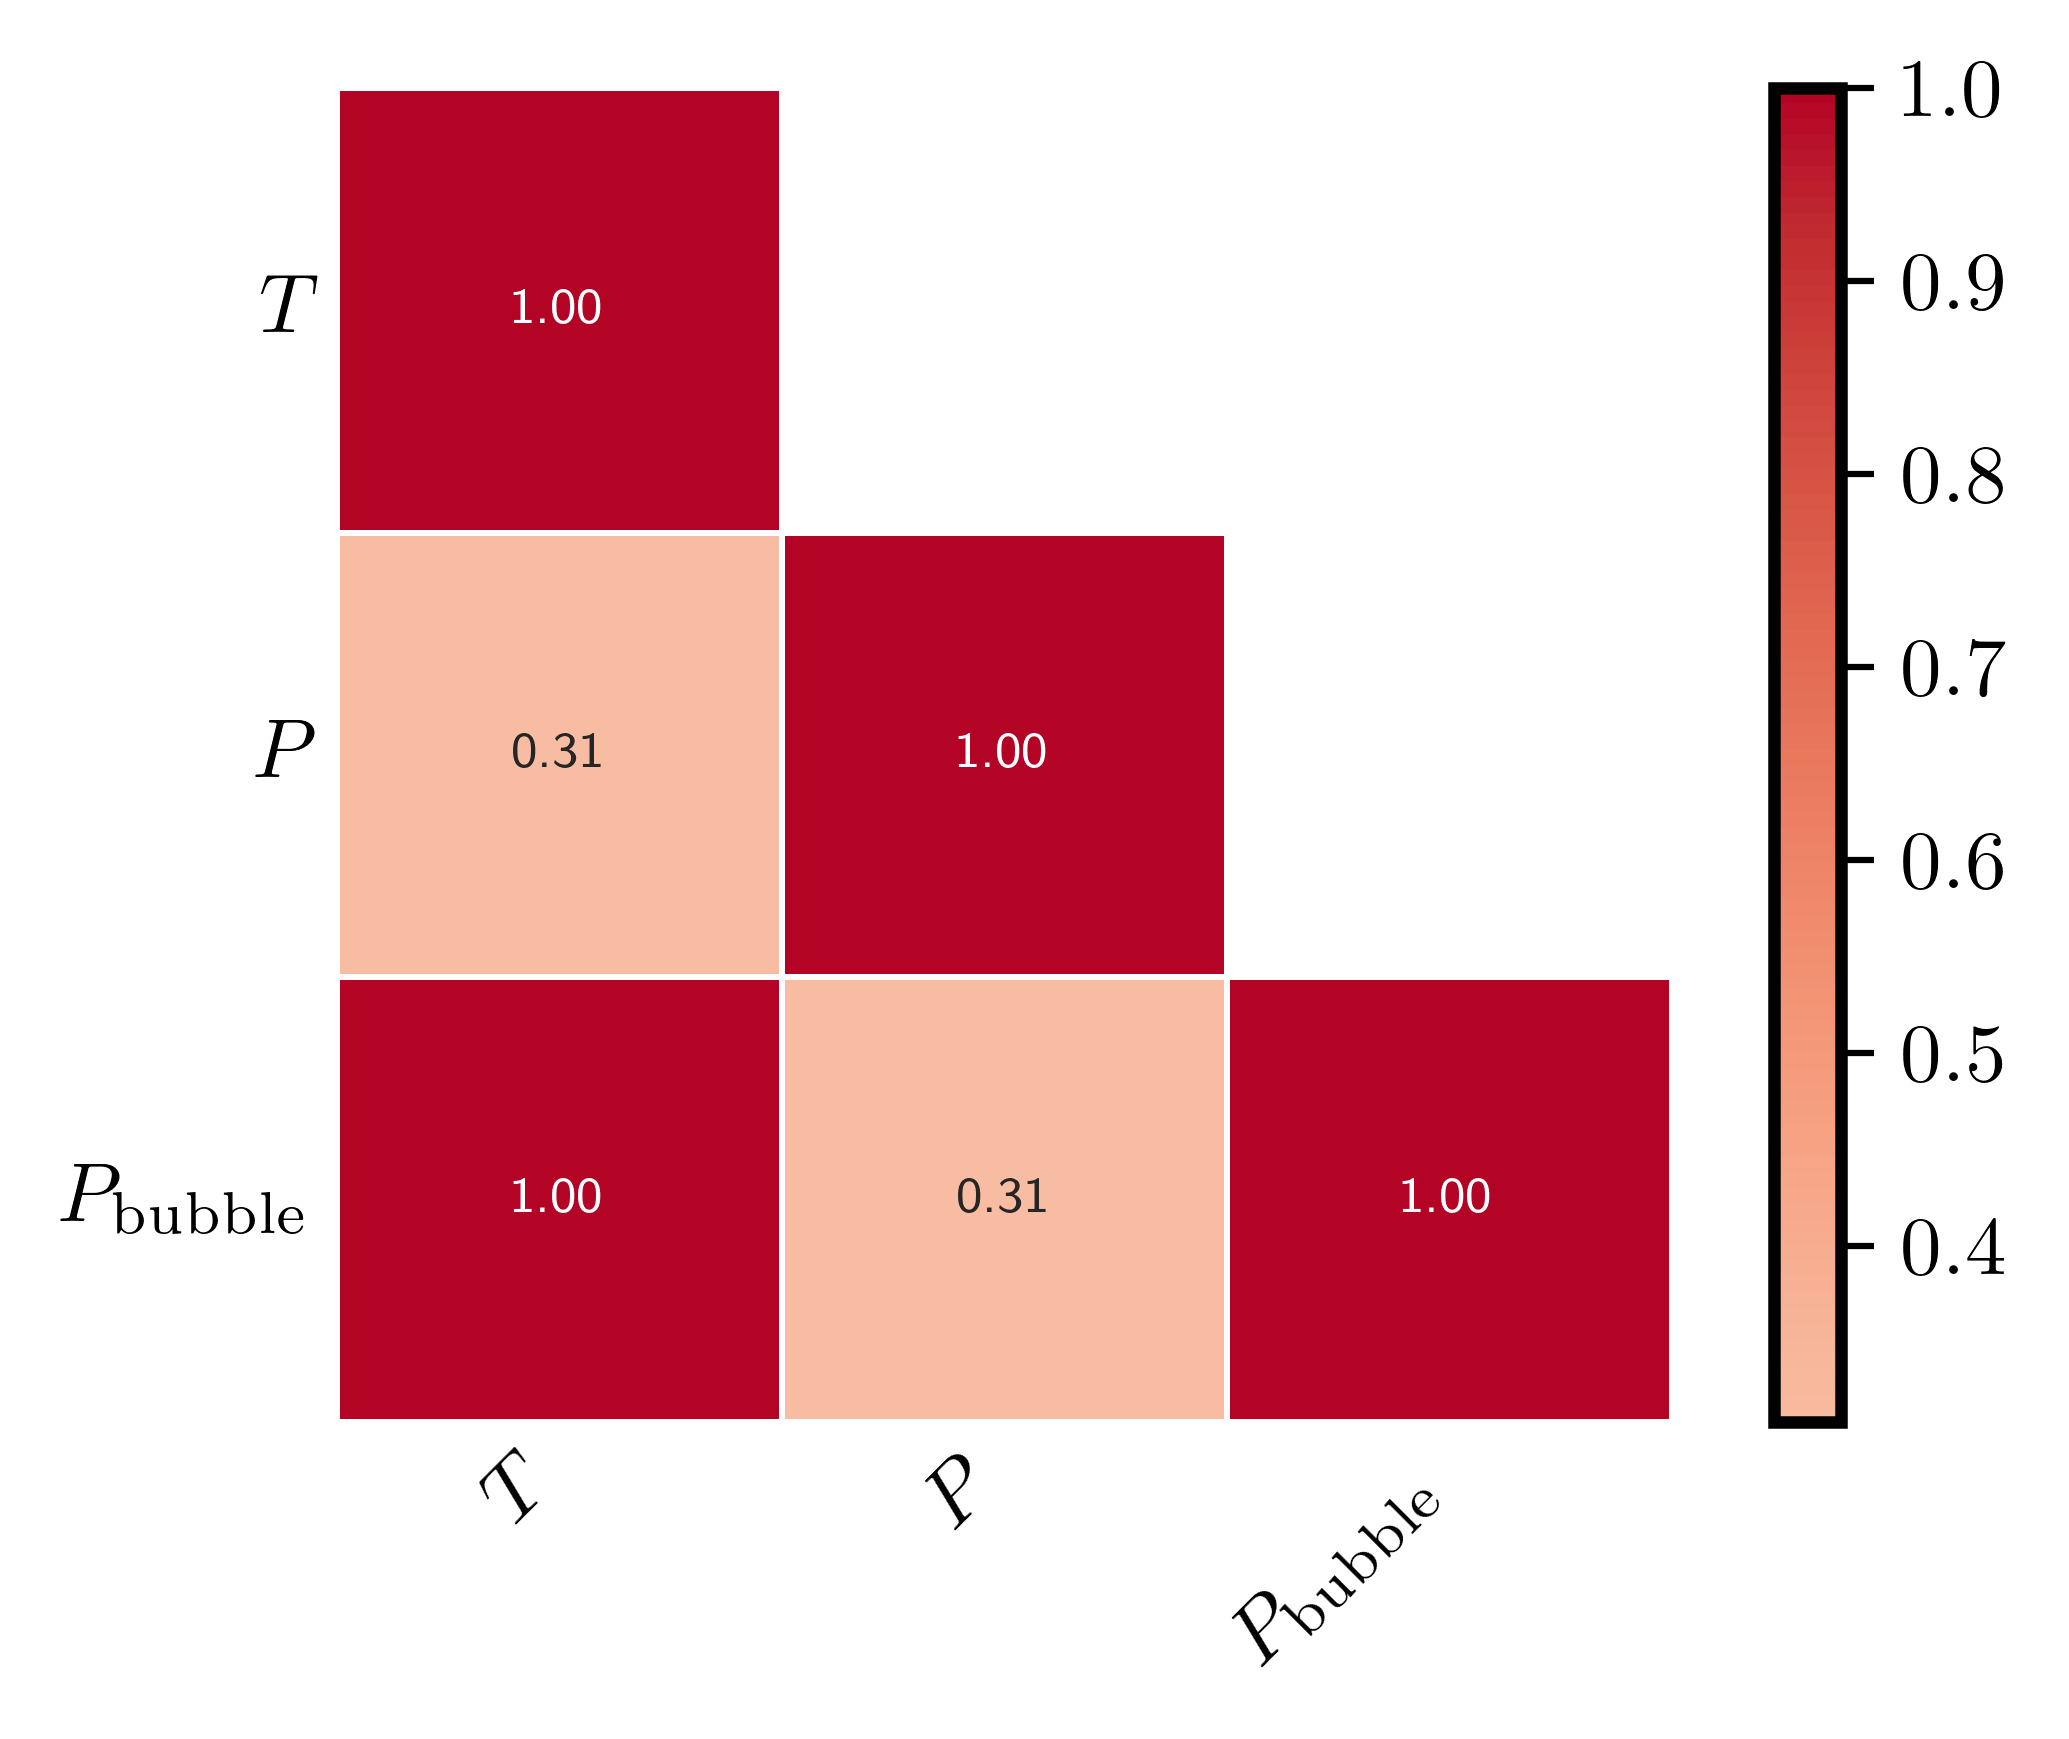

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [6]:
plot_correlation_heatmap(df, features, target, save_path="TabPFN_P_bubble_correlation", folder=PLOT_FOLDER)

In [ ]:
# Train TabPFN model with HPO (10 Bayesian-opt trials)
tuned_model = TunedTabPFNRegressor(
    n_trials=10,
    metric="rmse",
    n_validation_size=0.2,
    shuffle_data=True,
    search_algorithm_type="tpe",
    device="auto",
    random_state=SEED,
    verbose=False,
)
tuned_model.fit(X_train, y_train)

# Predictions using best tuned model
y_train_pred = tuned_model.predict(X_train)
y_test_pred  = tuned_model.predict(X_test)
y_val_pred   = tuned_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, y_val=y_val, y_val_pred=y_val_pred)

In [ ]:
# --- HPO inspection -----------------------------------------------------------
print("=" * 60)
print(f"Best CV {tuned_model.metric.value.upper()}: {tuned_model.best_score_:.6f}")
print("Best hyperparameter configuration:")
for k, v in tuned_model.best_params_.items():
    print(f"  {k}: {v}")
print("=" * 60)

trials_records = []
for t in tuned_model.trials_.trials:
    if t["result"].get("status") != "ok":
        continue
    row = {"trial_id": t["tid"], "loss": t["result"]["loss"]}
    for param, vals in t["misc"]["vals"].items():
        row[param] = vals[0] if len(vals) else None
    trials_records.append(row)

trials_df = pd.DataFrame(trials_records).sort_values("loss").reset_index(drop=True)
print("\nTop 10 trials:")
print(trials_df.head(10))

os.makedirs(PLOT_FOLDER, exist_ok=True)
trials_df.to_csv(os.path.join(PLOT_FOLDER, f"TabPFN_{target}_hpo_trials.csv"), index=False)

with open(os.path.join(PLOT_FOLDER, f"TabPFN_{target}_best_config.json"), "w") as f:
    json.dump(
        {
            "best_score": float(tuned_model.best_score_),
            "metric": tuned_model.metric.value,
            "best_config": {k: (v.item() if hasattr(v, "item") else v)
                            for k, v in tuned_model.best_params_.items()},
        },
        f, indent=2, default=str,
    )
print(f"Saved best config + trial history to {PLOT_FOLDER}/")

# --- HPO visualizations -------------------------------------------------------
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

trials_plot = trials_df.sort_values("trial_id").reset_index(drop=True)

# 1) Convergence curve: trial loss + best-so-far overlay
fig, ax = ps.plot_init()
ax.plot(trials_plot["trial_id"], trials_plot["loss"],
        color=ps.colors[1], alpha=0.5, linewidth=1, label="Trial loss")
ax.plot(trials_plot["trial_id"], trials_plot["loss"].cummin(),
        color=ps.colors[0], linewidth=2, label="Best so far")
ax.set_xlabel("Trial", fontsize=ps.label_fontsize)
ax.set_ylabel(f"{tuned_model.metric.value.upper()} loss", fontsize=ps.label_fontsize)
ax.legend(fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
plt.tight_layout()
ps.save_plot(fig, f"TabPFN_{target}_hpo_convergence", folder=PLOT_FOLDER)
plt.show()

# 2) Hyperparameter importance: |Pearson r| with loss
hp_cols  = [c for c in trials_plot.columns if c not in ("trial_id", "loss")]
valid_hp = [c for c in hp_cols if trials_plot[c].nunique() > 1]
hp_corr  = trials_plot[valid_hp].corrwith(trials_plot["loss"]).abs().sort_values()

fig, ax = ps.plot_init()
ax.barh(hp_corr.index, hp_corr.values, color=ps.colors[0], edgecolor="white", linewidth=0.5)
ax.set_xlabel("|Pearson r| with loss", fontsize=ps.label_fontsize)
ax.set_ylabel("Hyperparameter", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
plt.tight_layout()
ps.save_plot(fig, f"TabPFN_{target}_hpo_hp_importance", folder=PLOT_FOLDER)
plt.show()

# 3) Parallel coordinates: top 8 HPs by variance, coloured by loss
top_hp = trials_plot[valid_hp].std().sort_values(ascending=False).head(8).index.tolist()
norm_df = trials_plot[top_hp].copy()
for c in top_hp:
    mn, mx = norm_df[c].min(), norm_df[c].max()
    norm_df[c] = (norm_df[c] - mn) / (mx - mn + 1e-12)

loss_norm = (trials_plot["loss"] - trials_plot["loss"].min()) / \
            (trials_plot["loss"].max() - trials_plot["loss"].min() + 1e-12)
cmap = plt.cm.RdYlGn_r  # red = high loss, green = low loss

fig, ax = ps.plot_init()
for i in range(len(norm_df)):
    ax.plot(range(len(top_hp)), norm_df.iloc[i][top_hp].values,
            color=cmap(loss_norm.iloc[i]), alpha=0.4, linewidth=0.8)
ax.set_xticks(range(len(top_hp)))
ax.set_xticklabels(top_hp, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Normalised value", fontsize=ps.label_fontsize)
sm = ScalarMappable(cmap=cmap,
                    norm=Normalize(vmin=trials_plot["loss"].min(),
                                   vmax=trials_plot["loss"].max()))
sm.set_array([])
fig.colorbar(sm, ax=ax, label=f"{tuned_model.metric.value.upper()} loss")
ps.apply_axis_style(ax)
plt.tight_layout()
ps.save_plot(fig, f"TabPFN_{target}_hpo_parallel_coords", folder=PLOT_FOLDER)
plt.show()

In [ ]:
# Save predictions for post-hoc outlier analysis (no retraining needed)
results_df = pd.DataFrame({
    "idx":       np.concatenate([y_train.index, y_test.index, y_val.index]),
    "actual":    np.concatenate([y_train.values, y_test.values, y_val.values]),
    "predicted": np.concatenate([y_train_pred,  y_test_pred,  y_val_pred]),
    "split":     ["train"]*len(y_train) + ["test"]*len(y_test) + ["val"]*len(y_val),
})

os.makedirs(PLOT_FOLDER, exist_ok=True)
results_df.to_csv(os.path.join(PLOT_FOLDER, f"TabPFN_{target}_predictions.csv"), index=False)
print(f"Predictions saved: {len(results_df)} rows")

# Save the fitted underlying TabPFN regressor (lean — best for inference)
best_tabpfn = tuned_model.best_model_
model_path = os.path.join(PLOT_FOLDER, f"TabPFN_{target}_model.joblib")
joblib.dump(best_tabpfn, model_path)
print(f"Model saved to: {model_path}")

# Also save the full tuner (keeps trial history, larger file)
tuner_path = os.path.join(PLOT_FOLDER, f"TabPFN_{target}_tuner.joblib")
joblib.dump(tuned_model, tuner_path)
print(f"Tuner saved to: {tuner_path}")

In [ ]:
# 5-fold cross-validation on the *tuned* configuration — single pass, all 3 metrics.
# Using best_model_ avoids re-running the 10-trial HPO inside every fold.
best_tabpfn = tuned_model.best_model_

cv_results = cross_validate(
    best_tabpfn, X, y, cv=5,
    scoring={
        "r2":   "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae":  "neg_mean_absolute_error",
    },
    n_jobs=n_cpus,
)

cv_r2_scores   = cv_results["test_r2"]
cv_rmse_scores = -cv_results["test_rmse"]
cv_mae_scores  = -cv_results["test_mae"]

print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
print(f"Mean CV R²:   {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAE Scores:  {cv_mae_scores}")
print(f"Mean CV MAE:  {cv_mae_scores.mean():.6f} (+/- {cv_mae_scores.std() * 2:.6f})")

In [10]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="P_bubble",
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

In [ ]:
# Parity plot
post.plot_parity(model_name="TabPFN", save_path="TabPFN_P_bubble_parity_plot", folder=PLOT_FOLDER,
                 cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean())

In [ ]:
# Residual distribution
post.plot_residual_distribution(save_path="TabPFN_P_bubble_residual_distribution", folder=PLOT_FOLDER,
                                cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean())

In [ ]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="TabPFN_P_bubble_residual_vs_predicted", folder=PLOT_FOLDER,
                                cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean())

In [ ]:
# --- Permutation feature importance (computation) ---
best_tabpfn = tuned_model.best_model_

perm = permutation_importance(
    best_tabpfn,
    X_test,
    y_test,
    n_repeats=10,
    random_state=SEED,
    scoring="neg_root_mean_squared_error",
    n_jobs=n_cpus,
)

perm_df = (
    pd.DataFrame({
        "feature":         features,
        "importance_mean": perm.importances_mean,
        "importance_std":  perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
print("Permutation importance (drop in score when feature is shuffled):")
print(perm_df)

os.makedirs(PLOT_FOLDER, exist_ok=True)
perm_df.to_csv(
    os.path.join(PLOT_FOLDER, f"TabPFN_{target}_permutation_importance.csv"),
    index=False,
)

# --- SHAP values (computation) ---
n_explain = min(100, len(X_test))
X_explain = X_test.iloc[:n_explain] if hasattr(X_test, "iloc") else X_test[:n_explain]

shap_values = get_shap_values(
    estimator=best_tabpfn,
    test_x=X_explain,
    attribute_names=features,
)

shap_arr = shap_values.values if hasattr(shap_values, "values") else np.asarray(shap_values)
if shap_arr.ndim == 3:
    shap_arr = shap_arr[:, :, 0]
mean_abs = np.abs(shap_arr).mean(axis=0)

shap_rank_df = (
    pd.DataFrame({"feature": features, "mean_abs_shap": mean_abs})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
shap_rank_df.to_csv(
    os.path.join(PLOT_FOLDER, f"TabPFN_{target}_shap_importance.csv"),
    index=False,
)
print("Mean |SHAP| ranking:")
print(shap_rank_df)

metrics["permutation_importance"] = perm_df.to_dict(orient="records")
metrics["shap_importance"]        = shap_rank_df.to_dict(orient="records")

In [ ]:
# --- Plots: permutation importance + SHAP ---
feature_labels = [ps.label_map.get(f, f) for f in features]

# 1) Permutation importance bar chart
fig, ax = ps.plot_init()
order = perm_df.iloc[::-1]
order_labels = [ps.label_map.get(f, f) for f in order["feature"]]
ax.barh(order_labels, order["importance_mean"],
        xerr=order["importance_std"],
        color=ps.colors[0], edgecolor="white", linewidth=0.5)
ax.set_xlabel(r"Increase in RMSE when feature is permuted", fontsize=ps.label_fontsize)
ax.set_ylabel("Feature", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
plt.tight_layout()
ps.save_plot(fig, f"TabPFN_{target}_permutation_importance", folder=PLOT_FOLDER)
plt.show()

# 2) Mean |SHAP| bar plot
fig, ax = ps.plot_init()
shap.plots.bar(shap_values, show=False)
ax = plt.gca()
ax.set_xlabel(r"Mean $|\mathrm{SHAP}|$", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
plt.tight_layout()
ps.save_plot(fig, f"TabPFN_{target}_shap_bar", folder=PLOT_FOLDER)
plt.show()

# 3) Beeswarm summary plot
fig, ax = ps.plot_init()
shap.summary_plot(shap_values, X_explain, feature_names=feature_labels,
                  show=False, plot_size=None)
ax = plt.gca()
ax.set_xlabel(r"SHAP value", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
plt.tight_layout()
ps.save_plot(fig, f"TabPFN_{target}_shap_summary", folder=PLOT_FOLDER)
plt.show()

# 4) Dependence plot for top feature
top_feature = shap_rank_df.iloc[0]["feature"]
top_feature_idx = features.index(top_feature)
fig, ax = ps.plot_init()
shap.dependence_plot(
    top_feature_idx,
    shap_arr,
    X_explain,
    feature_names=feature_labels,
    ax=ax,
    show=False,
)
ax.set_xlabel(ps.label_map.get(top_feature, top_feature), fontsize=ps.label_fontsize)
ax.set_ylabel(rf"SHAP value for {ps.label_map.get(top_feature, top_feature)}", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
plt.tight_layout()
ps.save_plot(fig, f"TabPFN_{target}_shap_dependence_{top_feature}", folder=PLOT_FOLDER)
plt.show()

In [ ]:
post.print_summary()

# Collect all metrics
metrics["cv_r2_scores"]    = cv_r2_scores.tolist()
metrics["cv_r2_mean"]      = float(cv_r2_scores.mean())
metrics["cv_r2_std"]       = float(cv_r2_scores.std())
metrics["cv_rmse_scores"]  = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]    = float(cv_rmse_scores.mean())
metrics["cv_rmse_std"]     = float(cv_rmse_scores.std())
metrics["cv_mae_scores"]   = cv_mae_scores.tolist()
metrics["cv_mae_mean"]     = float(cv_mae_scores.mean())
metrics["cv_mae_std"]      = float(cv_mae_scores.std())
metrics["model"]           = "TabPFN"
metrics["features"]        = features
metrics["target"]          = target
metrics["seed"]            = SEED
metrics["best_hyperparameters"] = {
    k: (v.item() if hasattr(v, "item") else v)
    for k, v in tuned_model.best_params_.items()
}
metrics["best_hpo_score"] = float(tuned_model.best_score_)
metrics["hpo_metric"]     = tuned_model.metric.value
metrics["hpo_n_trials"]   = tuned_model.n_trials

# Save metrics to JSON
os.makedirs(PLOT_FOLDER, exist_ok=True)
metrics_path = os.path.join(PLOT_FOLDER, f"TabPFN_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

In [15]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 0.54 minutes
